#4_Final_Model_Creation

In [31]:
import pandas as pd
import random

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/Colab Notebooks

/content/drive/MyDrive/Colab Notebooks


In [4]:
import pandas as pd
import pickle

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

import seaborn as sns
import matplotlib.pyplot as plt


In [5]:
df = pd.read_csv("preprocessed_fashion_customer_churn.csv")

In [6]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [9]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


 Accuracy: 0.8700

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92        72
           1       0.94      0.57      0.71        28

    accuracy                           0.87       100
   macro avg       0.90      0.78      0.81       100
weighted avg       0.88      0.87      0.86       100



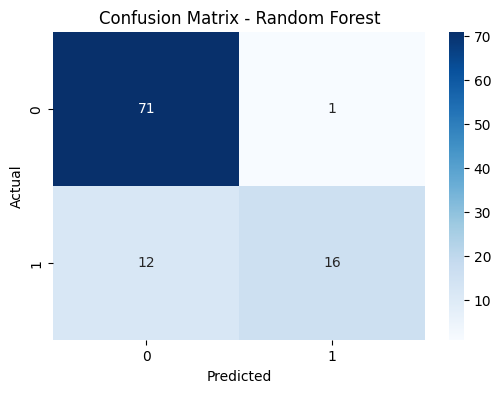

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [11]:
pickle.dump(model, open("fashion_churn_rf_model.pkl", "wb"))
print("\nModel saved as: fashion_churn_rf_model.pkl")


Model saved as: fashion_churn_rf_model.pkl


In [12]:
df_original = pd.read_csv("fashion_customer_churn.csv")

churn_counts = df_original["Churn"].value_counts()
continue_count = churn_counts.get("No", 0)
withdraw_count = churn_counts.get("Yes", 0)
total_customers = len(df_original)

print("\nCustomer Churn Summary")
print("========================")
print("Total Customers           :", total_customers)
print("Customers Continue (No)   :", continue_count)
print("Customers Withdraw (Yes)  :", withdraw_count)


Customer Churn Summary
Total Customers           : 500
Customers Continue (No)   : 359
Customers Withdraw (Yes)  : 141


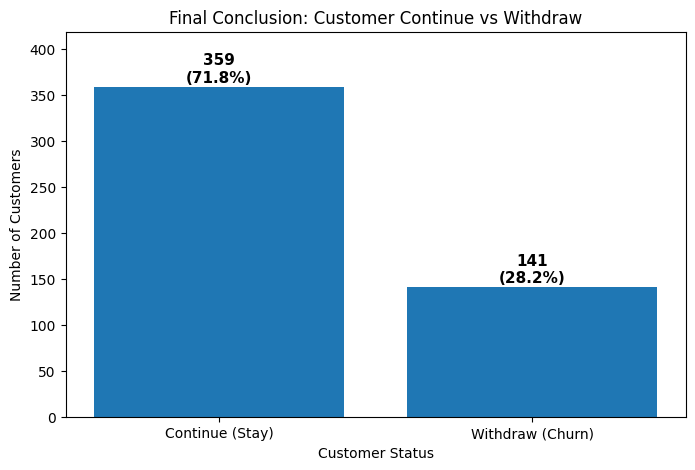


Final Customer Summary
Customers Continue (Stay): 359
Customers Withdraw (Churn): 141


In [13]:
# =========================
# BAR CHART: CONTINUE VS WITHDRAW
# =========================
labels = ["Continue (Stay)", "Withdraw (Churn)"]
values = [continue_count, withdraw_count]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values)
plt.title("Final Conclusion: Customer Continue vs Withdraw")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

for i, bar in enumerate(bars):
    height = bar.get_height()
    percentage = (values[i] / total_customers) * 100
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        f"{int(height)}\n({percentage:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.ylim(0, max(values) + 60)
plt.show()

print("\nFinal Customer Summary")
print("========================")
print("Customers Continue (Stay):", continue_count)
print("Customers Withdraw (Churn):", withdraw_count)

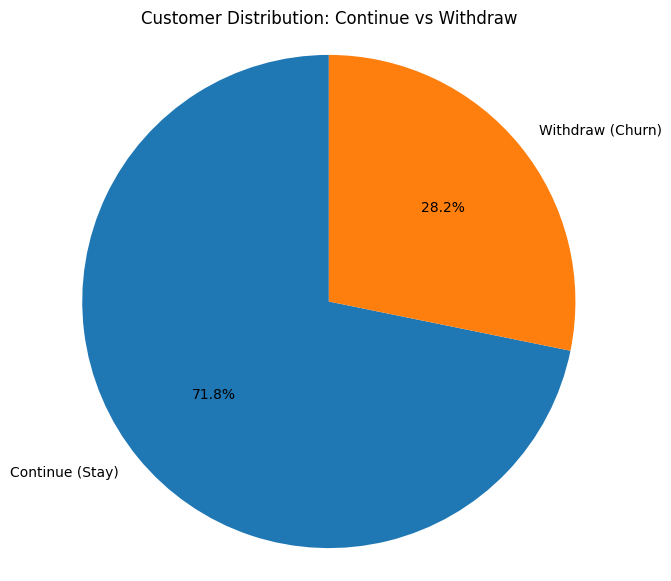

In [14]:
# =========================
# PIE CHART: CONTINUE VS WITHDRAW
# =========================
labels = ["Continue (Stay)", "Withdraw (Churn)"]
sizes = [continue_count, withdraw_count]

plt.figure(figsize=(7, 7))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Customer Distribution: Continue vs Withdraw")
plt.axis('equal')
plt.show()


In [15]:
loaded_model = pickle.load(open("fashion_churn_rf_model.pkl", "rb"))
label_encoders = pickle.load(open("fashion_rf_label_encoders.pkl", "rb"))
target_encoder = pickle.load(open("fashion_rf_target_encoder.pkl", "rb"))

In [16]:
result = loaded_model.predict(X_test)

In [17]:
# =========================
# SINGLE CUSTOMER PREDICTION
# =========================
preinput = pd.DataFrame([{
    "Gender": "Male",
    "Age": 30,
    "City": "Mumbai",
    "MembershipType": "Free",
    "PreferredCategory": "Men",
    "BrandPreference": "Nike",
    "TotalOrders": 3,
    "TotalSpent": 2500,
    "AverageOrderValue": 833.33,
    "LastPurchaseDaysAgo": 140,
    "PurchaseFrequencyPerMonth": 0.5,
    "AppLoginFrequency": 2,
    "ProductViews": 10,
    "WishlistCount": 1,
    "CartAdditions": 0,
    "CouponUsageCount": 0,
    "SaleEventParticipation": 0,
    "ReturnCount": 6,
    "ExchangeCount": 2,
    "SizeIssueReturns": 3,
    "CancelCount": 3,
    "RefundRequests": 3,
    "DeliveryDelayCount": 2,
    "SupportTickets": 5,
    "SatisfactionScore": 2.1
}])

for col in preinput.columns:
    if col in label_encoders:
        preinput[col] = label_encoders[col].transform(preinput[col])

result = loaded_model.predict(preinput)
final_result = target_encoder.inverse_transform(result)

print("\nSingle Customer Prediction")
print("========================")
print("Encoded Prediction:", result)
print("Final Prediction:", final_result)



Single Customer Prediction
Encoded Prediction: [1]
Final Prediction: ['Yes']


In [18]:
df = pd.read_csv("fashion_customer_churn.csv")

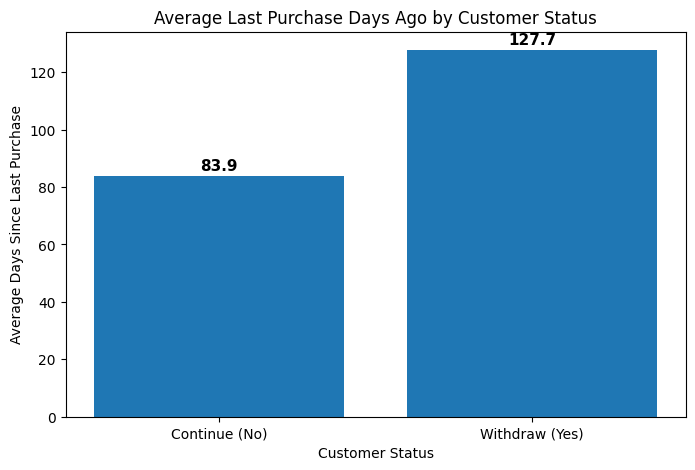

In [19]:
# =========================
# LAST PURCHASE DAYS AGO VS CHURN
# =========================
avg_last_purchase = df.groupby("Churn")["LastPurchaseDaysAgo"].mean()
avg_last_purchase.index = ["Continue (No)", "Withdraw (Yes)"]

plt.figure(figsize=(8, 5))
bars = plt.bar(avg_last_purchase.index, avg_last_purchase.values)
plt.title("Average Last Purchase Days Ago by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Days Since Last Purchase")
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.1f}",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )
plt.show()

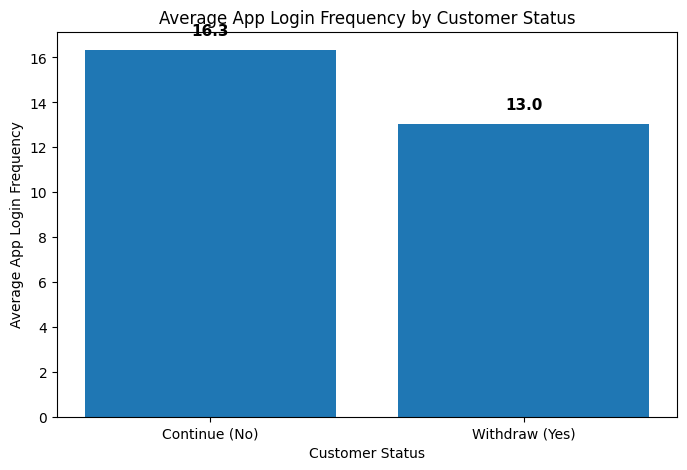

In [20]:
# =========================
# APP LOGIN FREQUENCY VS CHURN
# =========================
avg_login = df.groupby("Churn")["AppLoginFrequency"].mean()
avg_login.index = ["Continue (No)", "Withdraw (Yes)"]

plt.figure(figsize=(8, 5))
bars = plt.bar(avg_login.index, avg_login.values)
plt.title("Average App Login Frequency by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Average App Login Frequency")
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.1f}",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )
plt.show()

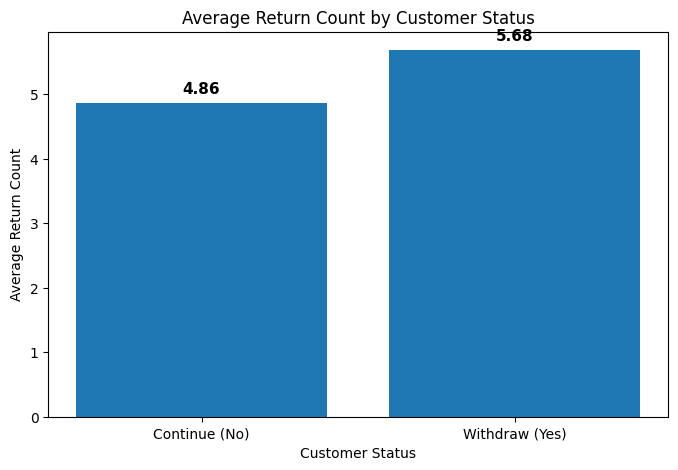

In [21]:
# =========================
# RETURN COUNT VS CHURN
# =========================
avg_return = df.groupby("Churn")["ReturnCount"].mean()
avg_return.index = ["Continue (No)", "Withdraw (Yes)"]

plt.figure(figsize=(8, 5))
bars = plt.bar(avg_return.index, avg_return.values)
plt.title("Average Return Count by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Return Count")
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        f"{height:.2f}",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )
plt.show()


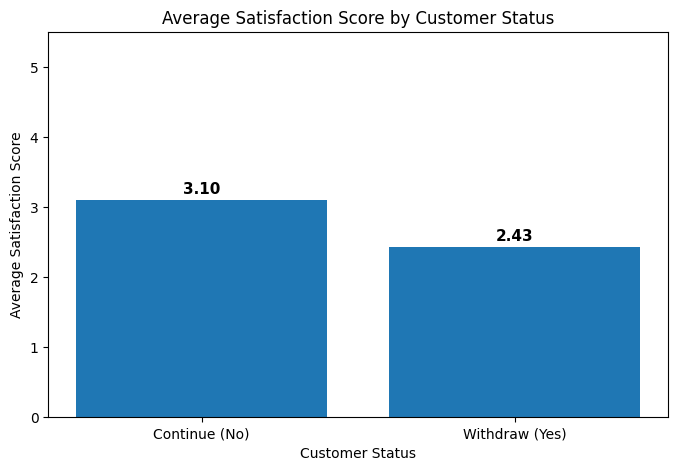

In [22]:
# =========================
# SATISFACTION SCORE VS CHURN
# =========================
avg_satisfaction = df.groupby("Churn")["SatisfactionScore"].mean()
avg_satisfaction.index = ["Continue (No)", "Withdraw (Yes)"]

plt.figure(figsize=(8, 5))
bars = plt.bar(avg_satisfaction.index, avg_satisfaction.values)
plt.title("Average Satisfaction Score by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Satisfaction Score")
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.05,
        f"{height:.2f}",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )
plt.ylim(0, 5.5)
plt.show()

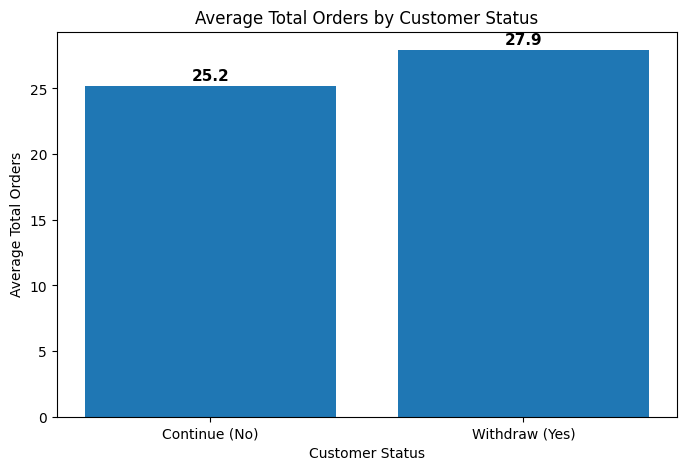

In [23]:
# =========================
# TOTAL ORDERS VS CHURN
# =========================
avg_orders = df.groupby("Churn")["TotalOrders"].mean()
avg_orders.index = ["Continue (No)", "Withdraw (Yes)"]

plt.figure(figsize=(8,5))
bars = plt.bar(avg_orders.index, avg_orders.values)
plt.title("Average Total Orders by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Total Orders")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.2, f"{height:.1f}",
             ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.show()

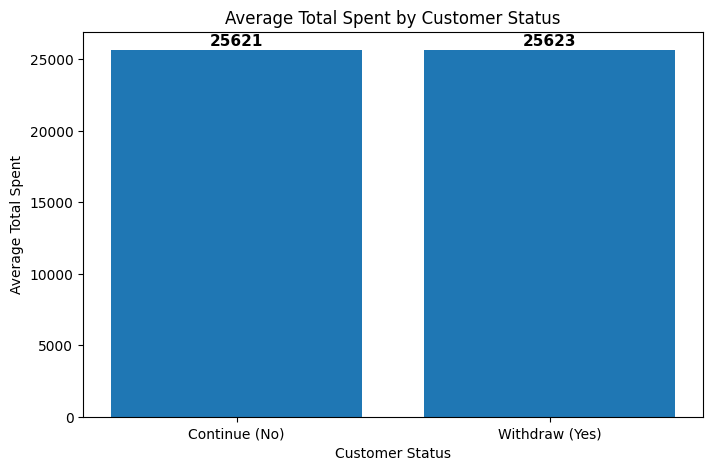

In [24]:
# =========================
# TOTAL SPENT VS CHURN
# =========================
avg_spent = df.groupby("Churn")["TotalSpent"].mean()
avg_spent.index = ["Continue (No)", "Withdraw (Yes)"]

plt.figure(figsize=(8,5))
bars = plt.bar(avg_spent.index, avg_spent.values)
plt.title("Average Total Spent by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Total Spent")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 100, f"{height:.0f}",
             ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.show()


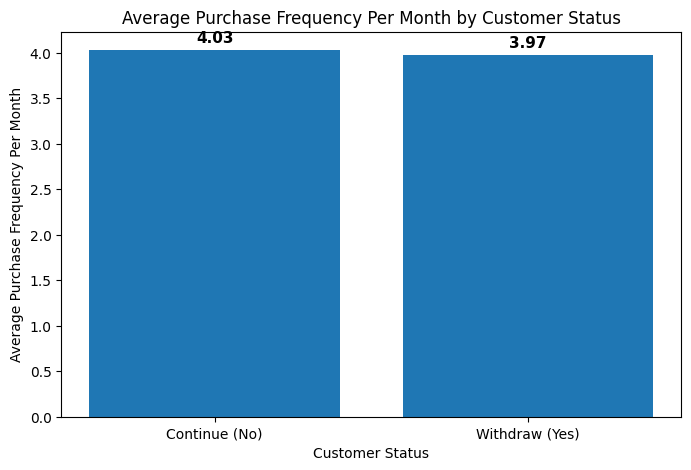

In [25]:
# =========================
# PURCHASE FREQUENCY PER MONTH VS CHURN
# =========================
avg_freq = df.groupby("Churn")["PurchaseFrequencyPerMonth"].mean()
avg_freq.index = ["Continue (No)", "Withdraw (Yes)"]

plt.figure(figsize=(8,5))
bars = plt.bar(avg_freq.index, avg_freq.values)
plt.title("Average Purchase Frequency Per Month by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Purchase Frequency Per Month")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.05, f"{height:.2f}",
             ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.show()


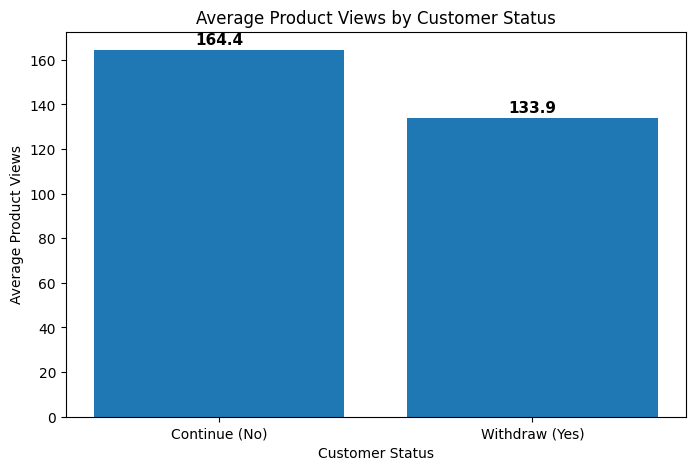

In [26]:
# =========================
# PRODUCT VIEWS VS CHURN
# =========================
avg_views = df.groupby("Churn")["ProductViews"].mean()
avg_views.index = ["Continue (No)", "Withdraw (Yes)"]

plt.figure(figsize=(8,5))
bars = plt.bar(avg_views.index, avg_views.values)
plt.title("Average Product Views by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Product Views")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f"{height:.1f}",
             ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.show()

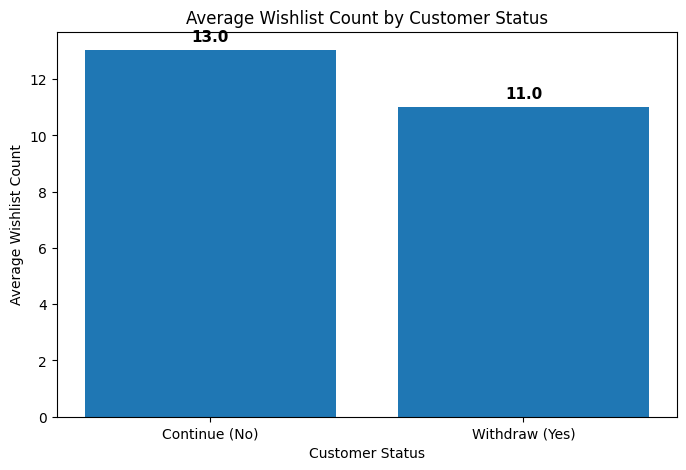

In [27]:
# =========================
# WISHLIST COUNT VS CHURN
# =========================
avg_wishlist = df.groupby("Churn")["WishlistCount"].mean()
avg_wishlist.index = ["Continue (No)", "Withdraw (Yes)"]

plt.figure(figsize=(8,5))
bars = plt.bar(avg_wishlist.index, avg_wishlist.values)
plt.title("Average Wishlist Count by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Wishlist Count")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.2, f"{height:.1f}",
             ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.show()


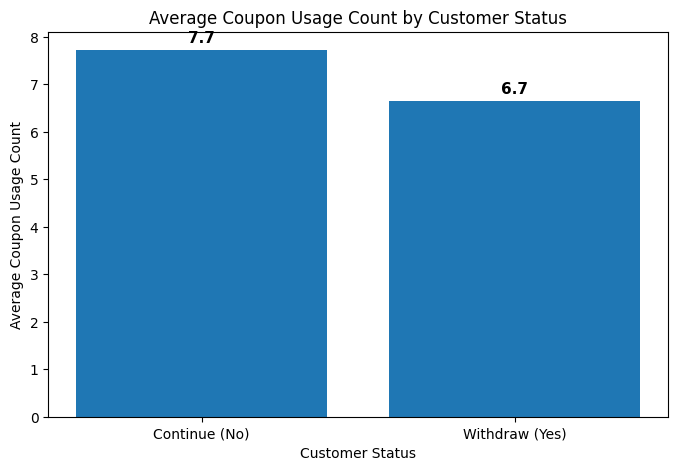

In [28]:
# =========================
# COUPON USAGE COUNT VS CHURN
# =========================
avg_coupon = df.groupby("Churn")["CouponUsageCount"].mean()
avg_coupon.index = ["Continue (No)", "Withdraw (Yes)"]

plt.figure(figsize=(8,5))
bars = plt.bar(avg_coupon.index, avg_coupon.values)
plt.title("Average Coupon Usage Count by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Average Coupon Usage Count")
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1, f"{height:.1f}",
             ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.show()

In [29]:
# =========================
# WIN-BACK FORECAST DETAILS
# =========================
churned_customers = df[df["Churn"] == "Yes"].copy()

churned_customers["WinBackScore"] = (
    churned_customers["AppLoginFrequency"] * 0.25 +
    churned_customers["ProductViews"] * 0.20 +
    churned_customers["WishlistCount"] * 0.15 +
    churned_customers["CouponUsageCount"] * 0.15 +
    churned_customers["SatisfactionScore"] * 10 * 0.25
)

def classify_return(score):
    if score >= 25:
        return "High Chance to Return"
    elif score >= 15:
        return "Medium Chance to Return"
    else:
        return "Low Chance to Return"

churned_customers["ReturnForecast"] = churned_customers["WinBackScore"].apply(classify_return)
forecast_counts = churned_customers["ReturnForecast"].value_counts()

print("\nChurned Customer Return Forecast")
print("==================================")
print(forecast_counts)

print("\nSample Forecast Results:")
print(churned_customers[["CustomerID", "AppLoginFrequency", "ProductViews", "WishlistCount", "CouponUsageCount", "SatisfactionScore", "WinBackScore", "ReturnForecast"]].head(10))



Churned Customer Return Forecast
ReturnForecast
High Chance to Return      99
Medium Chance to Return    33
Low Chance to Return        9
Name: count, dtype: int64

Sample Forecast Results:
   CustomerID  AppLoginFrequency  ProductViews  WishlistCount  \
3       C1004                 30           290              7   
5       C1006                 17           133             17   
10      C1011                  4           132              6   
12      C1013                 11            34              1   
15      C1016                 10           112             22   
16      C1017                  6           231             17   
23      C1024                 29            59             24   
25      C1026                  3            75              4   
27      C1028                 13           293             21   
28      C1029                 18            31             11   

    CouponUsageCount  SatisfactionScore  WinBackScore           ReturnForecast  
3           

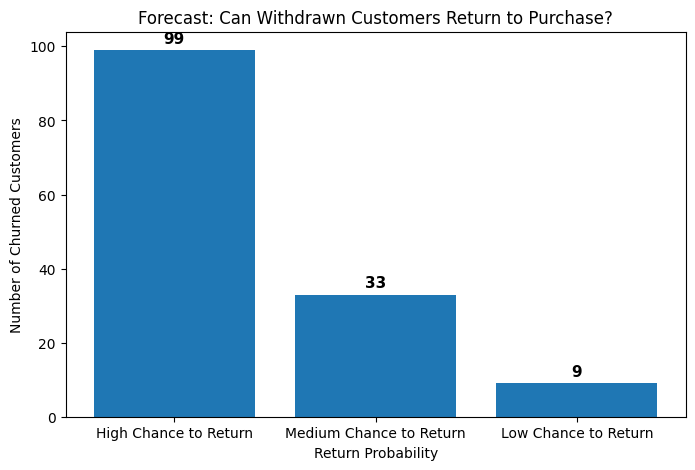

In [30]:
# =========================
# WIN-BACK FORECAST GRAPH
# =========================
plt.figure(figsize=(8,5))
bars = plt.bar(forecast_counts.index, forecast_counts.values)

plt.title("Forecast: Can Withdrawn Customers Return to Purchase?")
plt.xlabel("Return Probability")
plt.ylabel("Number of Churned Customers")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, str(int(height)),
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.show()